# TP2 — Visión por Computadora I

**Tema:** Detección automática de máximo enfoque en video mediante análisis espectral (Clase 3)

**Alumno:** Ailen Muñoz, Romero Federico

---

### Objetivo

Implementar un detector de máximo enfoque sobre un video (`focus_video.mov`) aplicando técnicas de análisis espectral similares a las que utilizan las cámaras digitales modernas para autofoco.

Se implementa la métrica de nitidez propuesta en el paper *"Image Sharpness Measure for Blurred Images in Frequency Domain"* (De, K. & Masilamani, V., 2013) y se la aplica a cada frame del video en dos experimentos:

1. Medición sobre el frame completo.
2. Medición sobre una ROI central (5% y 10% del área total del frame).

Para cada experimento se detecta automáticamente, y sin intervención manual, la región de frames donde el algoritmo entiende que el video está en foco.

Como punto extra, se aplica *unsharp masking* sobre los frames para expandir artificialmente la zona de enfoque detectada.

### Cómo leer este notebook

- Las cajas con **fondo y borde verde** contienen las conclusiones del equipo.
- El resto de las celdas están agrupadas por punto y contienen el código relativo a ese punto.

## Setup

Importamos las librerías necesarias. El video, el notebook y los resultados generados viven todos en esta misma carpeta (`Codigo/TP2/`).

In [1]:
import os

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# El video vive junto a este notebook, en la misma carpeta (Codigo/TP2/).
VIDEO_PATH = "focus_video.mov"

assert os.path.isfile(VIDEO_PATH), f"No se encontró {VIDEO_PATH}. Revisar desde dónde se corre el notebook."
VIDEO_PATH

'focus_video.mov'

## Parte 1 — Métrica de nitidez en el dominio de la frecuencia (FM)

El paper propone una métrica (*Frequency Domain Image Blur Measure*, **FM**) que cuantifica cuánto contenido de **alta frecuencia** tiene una imagen: una imagen nítida tiene bordes y detalle fino, que se traducen en energía en las frecuencias altas del espectro de Fourier; una imagen borrosa concentra casi toda su energía en las frecuencias bajas (cerca del centro del espectro).

**Algoritmo (dada una imagen `I` de `M x N`):**

1. Calcular `F`, la Transformada de Fourier 2D de `I`.
2. Calcular `Fc`, corriendo el origen de `F` al centro del espectro (`fftshift`).
3. Calcular `AF = abs(Fc)`, el módulo del espectro centrado.
4. Calcular `M_max = max(AF)`, el valor máximo de todo el espectro.
5. Calcular `T_H`, la cantidad de píxeles de `AF` cuyo valor supera un umbral `thres = M_max / 1000`.
6. La métrica final es `FM = T_H / (M x N)`: la **fracción de píxeles del espectro que tiene energía significativa**. Cuanto mayor es `FM`, más contenido de alta frecuencia (más nítida) es la imagen.

La implementamos como una única función encapsulada y reutilizable, para poder aplicarla tanto a un frame completo como a una ROI de cualquier tamaño.

In [2]:
def frequency_domain_blur_measure(image: np.ndarray, thres_ratio: float = 1000.0) -> float:

    if image.ndim == 3:
        image = cv.cvtColor(image, cv.COLOR_BGR2GRAY)

    img = image.astype(np.float64)
    M, N = img.shape

    F = np.fft.fft2(img)          # Paso 1: FFT 2D
    Fc = np.fft.fftshift(F)       # Paso 2: centrar el espectro
    AF = np.abs(Fc)                # Paso 3: módulo del espectro centrado

    M_max = np.max(AF)             # Paso 4
    thres = M_max / thres_ratio    # Paso 5
    T_H = np.count_nonzero(AF > thres)

    FM = T_H / (M * N)              # Paso 6
    return FM

### 1.1 Prueba rápida de la métrica

Antes de aplicarla sobre las 171 frames del video, validamos que la métrica se comporta como se espera: tomamos un frame razonablemente nítido (uno cercano a la mitad del clip, donde suele estar el foco) y una versión artificialmente desenfocada (blur gaussiano) del mismo frame, y verificamos que `FM` sea mayor en el nítido.

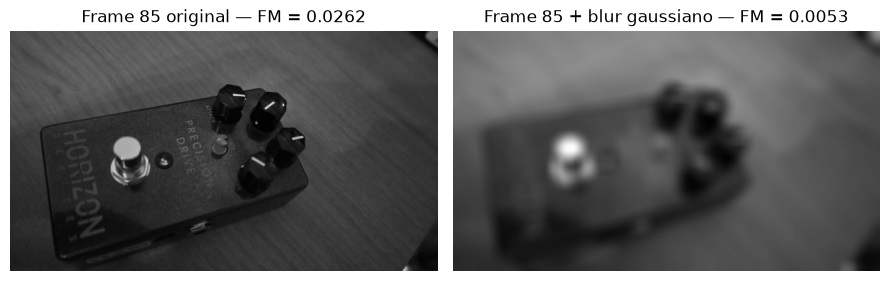

OK: FM(nítido)=0.0262 > FM(borroso)=0.0053


In [3]:
cap = cv.VideoCapture(VIDEO_PATH)
total_frames_video = int(cap.get(cv.CAP_PROP_FRAME_COUNT))
frame_idx_prueba = total_frames_video // 2  # frame cercano a la mitad del clip
cap.set(cv.CAP_PROP_POS_FRAMES, frame_idx_prueba)
ret, frame_test = cap.read()
cap.release()
assert ret, "No se pudo leer un frame de prueba del video"

frame_test_gray = cv.cvtColor(frame_test, cv.COLOR_BGR2GRAY)
frame_test_blur = cv.GaussianBlur(frame_test_gray, (25, 25), sigmaX=10)

fm_sharp = frequency_domain_blur_measure(frame_test_gray)
fm_blur = frequency_domain_blur_measure(frame_test_blur)

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
axes[0].imshow(frame_test_gray, cmap="gray")
axes[0].set_title(f"Frame {frame_idx_prueba} original — FM = {fm_sharp:.4f}")
axes[0].axis("off")

axes[1].imshow(frame_test_blur, cmap="gray")
axes[1].set_title(f"Frame {frame_idx_prueba} + blur gaussiano — FM = {fm_blur:.4f}")
axes[1].axis("off")

fig.tight_layout()
plt.show()

assert fm_sharp > fm_blur, "La métrica debería dar mayor valor para la imagen más nítida"
print(f"OK: FM(nítido)={fm_sharp:.4f} > FM(borroso)={fm_blur:.4f}")

## Parte 2 — Lectura del video

Leemos todos los frames del video y los convertimos a escala de grises: la métrica del paper opera sobre la intensidad de la imagen, no sobre el color.

In [4]:
def leer_frames(video_path: str) -> list:
    """Lee todos los frames de un video y los devuelve como lista de arrays BGR."""
    cap = cv.VideoCapture(video_path)
    if not cap.isOpened():
        raise IOError(f"No se pudo abrir el video: {video_path}")

    frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(frame)

    fps = cap.get(cv.CAP_PROP_FPS)
    cap.release()
    return frames, fps


frames_bgr, fps = leer_frames(VIDEO_PATH)
frames_gray = [cv.cvtColor(f, cv.COLOR_BGR2GRAY) for f in frames_bgr]

n_frames = len(frames_gray)
alto, ancho = frames_gray[0].shape
print(f"Frames leídos: {n_frames}")
print(f"FPS: {fps:.2f}")
print(f"Resolución: {ancho}x{alto}")

Frames leídos: 171
FPS: 29.97
Resolución: 640x360


## Detección automática de la zona de máximo enfoque

Para devolver **automáticamente** los puntos de máximo enfoque, no nos quedamos solo con el frame de FM máximo: definimos la "zona de enfoque" como el **rango contiguo de frames alrededor del pico** cuyo valor de FM se mantiene por encima de un umbral relativo al máximo (por defecto, 90% del pico). Esto es más robusto que un único frame, ya que el enfoque real ocurre durante un rango de frames (ver curva de ejemplo del enunciado), no en un instante puntual.

La función es genérica: sirve tanto para la curva del frame completo como para las curvas de las ROIs.

In [5]:
def detectar_zona_enfoque(curva_fm: np.ndarray, rel_threshold: float = 0.9,
                           umbral: float = None, centro: int = None) -> dict:
    curva_fm = np.asarray(curva_fm)
    pico = int(np.argmax(curva_fm)) if centro is None else int(centro)
    umbral_efectivo = umbral if umbral is not None else rel_threshold * curva_fm[pico]

    inicio = pico
    while inicio > 0 and curva_fm[inicio - 1] >= umbral_efectivo:
        inicio -= 1

    fin = pico
    while fin < len(curva_fm) - 1 and curva_fm[fin + 1] >= umbral_efectivo:
        fin += 1

    return {"inicio": inicio, "fin": fin, "pico": pico,
            "fm_pico": float(curva_fm[pico]), "umbral": float(umbral_efectivo)}


def graficar_curva_fm(curva_fm: np.ndarray, zona: dict, titulo: str, color: str = "tab:blue"):
    """Grafica la evolución de FM frame a frame, marcando la zona de enfoque detectada."""
    frames_idx = np.arange(len(curva_fm))

    plt.figure(figsize=(10, 5))
    plt.scatter(frames_idx, curva_fm, s=14, color=color, label="FM por frame")
    plt.axvspan(zona["inicio"], zona["fin"], color="green", alpha=0.15,
                label=f"Zona de enfoque detectada [{zona['inicio']}, {zona['fin']}]")
    plt.axvline(zona["pico"], color="red", linestyle="--",
                label=f"Pico de enfoque (frame {zona['pico']})")
    plt.xlabel("Frame #")
    plt.ylabel("FM")
    plt.title(titulo)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## Experimento 1 — Métrica sobre el frame completo

Calculamos `FM` para cada frame del video, usando el frame completo (`M x N` = resolución del video), y detectamos automáticamente la zona de máximo enfoque.

Zona de enfoque detectada (frame completo): frames [80, 115]
Pico de enfoque: frame 109 (FM = 0.0278)


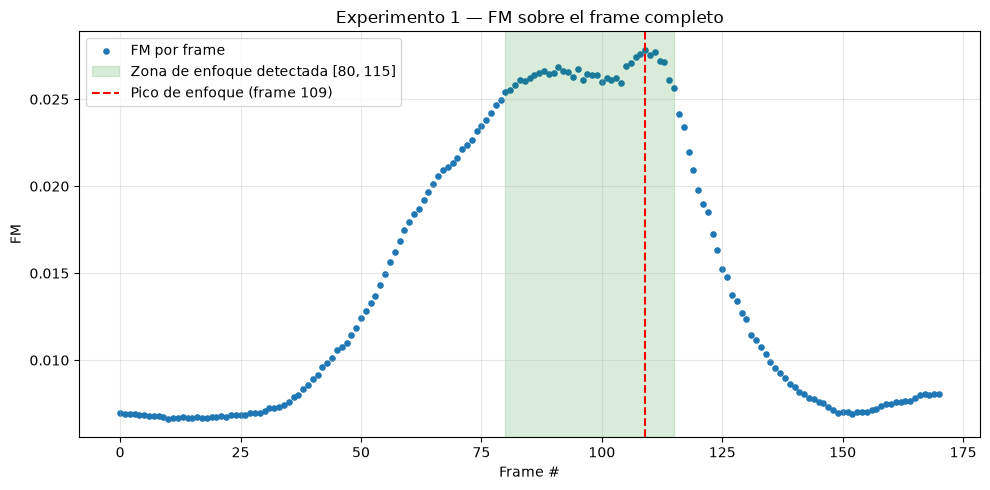

In [6]:
fm_full = np.array([frequency_domain_blur_measure(f) for f in frames_gray])
zona_full = detectar_zona_enfoque(fm_full)

print(f"Zona de enfoque detectada (frame completo): frames [{zona_full['inicio']}, {zona_full['fin']}]")
print(f"Pico de enfoque: frame {zona_full['pico']} (FM = {zona_full['fm_pico']:.4f})")

graficar_curva_fm(fm_full, zona_full, "Experimento 1 — FM sobre el frame completo")

Verificamos visualmente el resultado, comparando el frame de pico de enfoque contra un frame claramente fuera de foco (el primer frame del video).

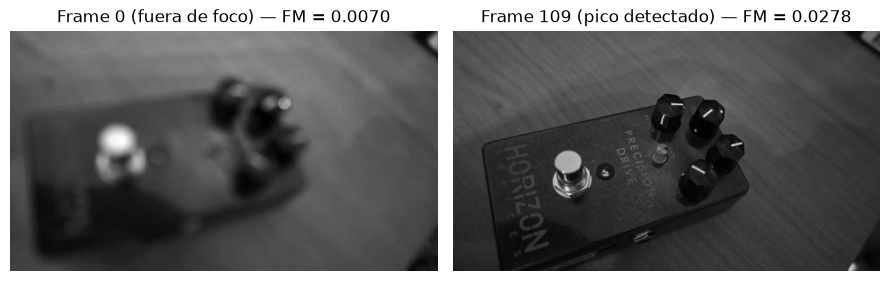

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
axes[0].imshow(frames_gray[0], cmap="gray")
axes[0].set_title(f"Frame 0 (fuera de foco) — FM = {fm_full[0]:.4f}")
axes[0].axis("off")

axes[1].imshow(frames_gray[zona_full["pico"]], cmap="gray")
axes[1].set_title(f"Frame {zona_full['pico']} (pico detectado) — FM = {zona_full['fm_pico']:.4f}")
axes[1].axis("off")

fig.tight_layout()
plt.show()

## Experimento 2 — Métrica sobre ROI central

Repetimos la medición, esta vez restringiendo el cálculo de `FM` a una ROI cuadrada centrada en el frame, cuya área es una fracción (5% o 10%) del área total. Al reducir el área analizada, se elimina el fondo y se aísla el efecto del enfoque sobre el objeto de interés en el centro de la escena.

In [8]:
def roi_central(frame: np.ndarray, area_fraction: float) -> np.ndarray:
    alto, ancho = frame.shape[:2]
    escala = np.sqrt(area_fraction)
    roi_alto = max(1, int(round(alto * escala)))
    roi_ancho = max(1, int(round(ancho * escala)))

    y0 = (alto - roi_alto) // 2
    x0 = (ancho - roi_ancho) // 2
    return frame[y0:y0 + roi_alto, x0:x0 + roi_ancho]


def roi_bbox(frame_shape: tuple, area_fraction: float) -> tuple:
    alto, ancho = frame_shape[:2]
    escala = np.sqrt(area_fraction)
    roi_alto = max(1, int(round(alto * escala)))
    roi_ancho = max(1, int(round(ancho * escala)))
    y0 = (alto - roi_alto) // 2
    x0 = (ancho - roi_ancho) // 2
    return x0, y0, roi_ancho, roi_alto

Antes de medir, visualizamos ambas ROIs (5% y 10% del área) superpuestas sobre el frame de pico de enfoque detectado en el Experimento 1.

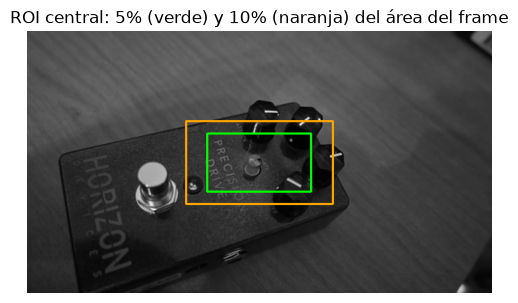

In [9]:
frame_ref = cv.cvtColor(frames_gray[zona_full["pico"]], cv.COLOR_GRAY2BGR)

colores = {0.05: (0, 255, 0), 0.10: (0, 165, 255)}  # BGR: verde (5%), naranja (10%)
for area_fraction, color in colores.items():
    x0, y0, w, h = roi_bbox(frame_ref.shape, area_fraction)
    cv.rectangle(frame_ref, (x0, y0), (x0 + w, y0 + h), color, 2)

plt.figure(figsize=(6, 4))
plt.imshow(cv.cvtColor(frame_ref, cv.COLOR_BGR2RGB))
plt.title("ROI central: 5% (verde) y 10% (naranja) del área del frame")
plt.axis("off")
plt.show()

ROI 5% del área — zona de enfoque: frames [107, 113], pico en frame 111 (FM = 0.4596)


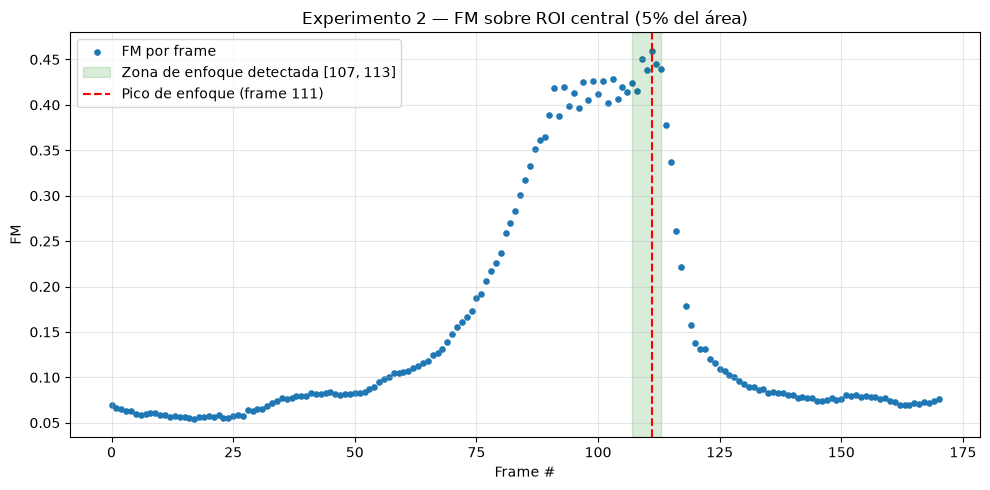

ROI 10% del área — zona de enfoque: frames [105, 113], pico en frame 111 (FM = 0.3529)


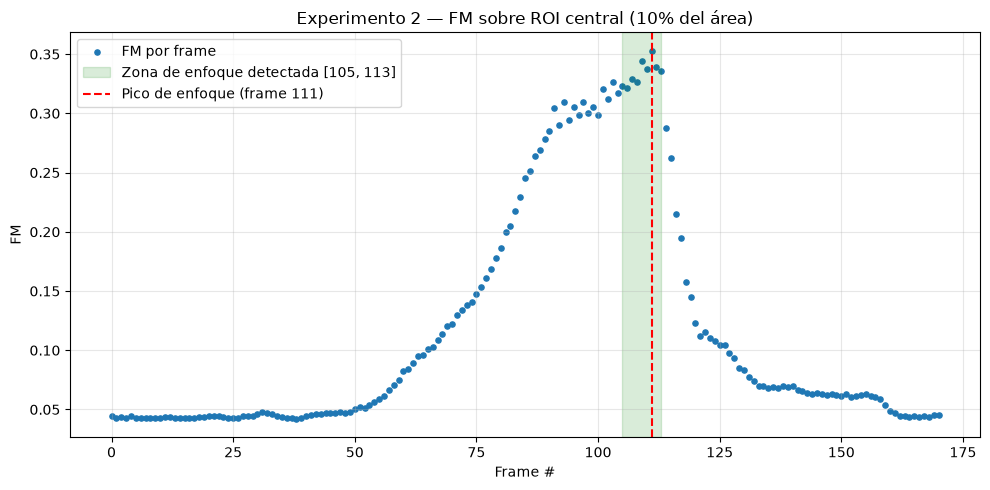

In [10]:
AREA_FRACTIONS = [0.05, 0.10]
resultados_roi = {}

for area_fraction in AREA_FRACTIONS:
    fm_roi = np.array([
        frequency_domain_blur_measure(roi_central(f, area_fraction)) for f in frames_gray
    ])
    zona_roi = detectar_zona_enfoque(fm_roi)
    resultados_roi[area_fraction] = {"fm": fm_roi, "zona": zona_roi}

    print(f"ROI {area_fraction:.0%} del área — zona de enfoque: "
          f"frames [{zona_roi['inicio']}, {zona_roi['fin']}], "
          f"pico en frame {zona_roi['pico']} (FM = {zona_roi['fm_pico']:.4f})")

    graficar_curva_fm(fm_roi, zona_roi, f"Experimento 2 — FM sobre ROI central ({area_fraction:.0%} del área)")

Comparamos ambas curvas de ROI junto con la del frame completo en un mismo gráfico, normalizando cada curva a su propio máximo para poder compararlas en la misma escala.

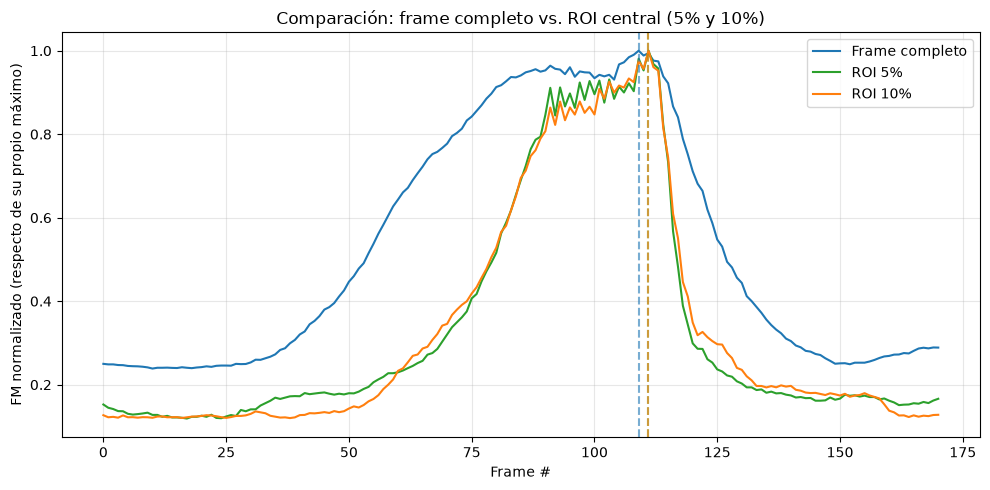

In [11]:
plt.figure(figsize=(10, 5))
frames_idx = np.arange(n_frames)

plt.plot(frames_idx, fm_full / fm_full.max(), label="Frame completo", color="tab:blue")
plt.plot(frames_idx, resultados_roi[0.05]["fm"] / resultados_roi[0.05]["fm"].max(),
         label="ROI 5%", color="tab:green")
plt.plot(frames_idx, resultados_roi[0.10]["fm"] / resultados_roi[0.10]["fm"].max(),
         label="ROI 10%", color="tab:orange")

for area_fraction, color in [(None, "tab:blue"), (0.05, "tab:green"), (0.10, "tab:orange")]:
    pico = zona_full["pico"] if area_fraction is None else resultados_roi[area_fraction]["zona"]["pico"]
    plt.axvline(pico, color=color, linestyle="--", alpha=0.6)

plt.xlabel("Frame #")
plt.ylabel("FM normalizado (respecto de su propio máximo)")
plt.title("Comparación: frame completo vs. ROI central (5% y 10%)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<div style="border:2px solid #8EB15C; background-color:#B1CF86; padding:14px 16px; border-radius:6px; color:#111;">

**Conclusiones**

- La métrica `FM` del paper distingue claramente frames enfocados de frames borrosos, tanto en la prueba sintética (Parte 1) como sobre el video real.
- El criterio de detección automática (rango contiguo por encima del 90% del pico) permite identificar no solo el instante de máximo enfoque sino toda la "zona" de foco, de forma consistente con la curva de ejemplo del enunciado.
- Restringir la medición a una ROI central (5% o 10%) aísla el efecto del objeto de interés del fondo de la escena (porque el objeto se posiciona centrado en la escena en general); comparar ambos tamaños de ROI permite evaluar el compromiso entre sensibilidad a la zona exacta de foco (ROI chica) y robustez al ruido (ROI grande).

</div>

## Punto extra — Unsharp masking para expandir la zona de enfoque

La idea: el *unsharp masking* refuerza el contenido de alta frecuencia que **ya está presente** en la imagen, sumándole (amplificada) la diferencia entre la imagen y una versión suavizada de sí misma. Un frame cercano al punto real de foco, aunque levemente desenfocado, todavía conserva algo de ese detalle fino; al reforzarlo, su `FM` sube y puede llegar a superar un umbral que antes no alcanzaba. Un frame muy lejos del foco ya perdió ese detalle (el desenfoque real se lo quitó) y el filtro no tiene qué amplificar, así que su `FM` casi no cambia.

El resultado esperado es que la **zona de enfoque detectada se expanda** alrededor del mismo pico real, sin haber cambiado en qué frame está el mejor foco.

In [12]:
def unsharp_masking(image: np.ndarray, sigma: float = 2.0, amount: float = 1.5) -> np.ndarray:
    img = image.astype(np.float32)
    suavizada = cv.GaussianBlur(img, (0, 0), sigmaX=sigma)
    detalle = img - suavizada
    reforzada = img + amount * detalle
    return np.clip(reforzada, 0, 255).astype(np.uint8)

Antes de aplicarlo sobre todo el video, comparamos visualmente un par de frames que quedaron **fuera** de la zona de enfoque original (Experimento 1), antes y después del refuerzo, para verificar que efectivamente ganan nitidez aparente (y `FM`).

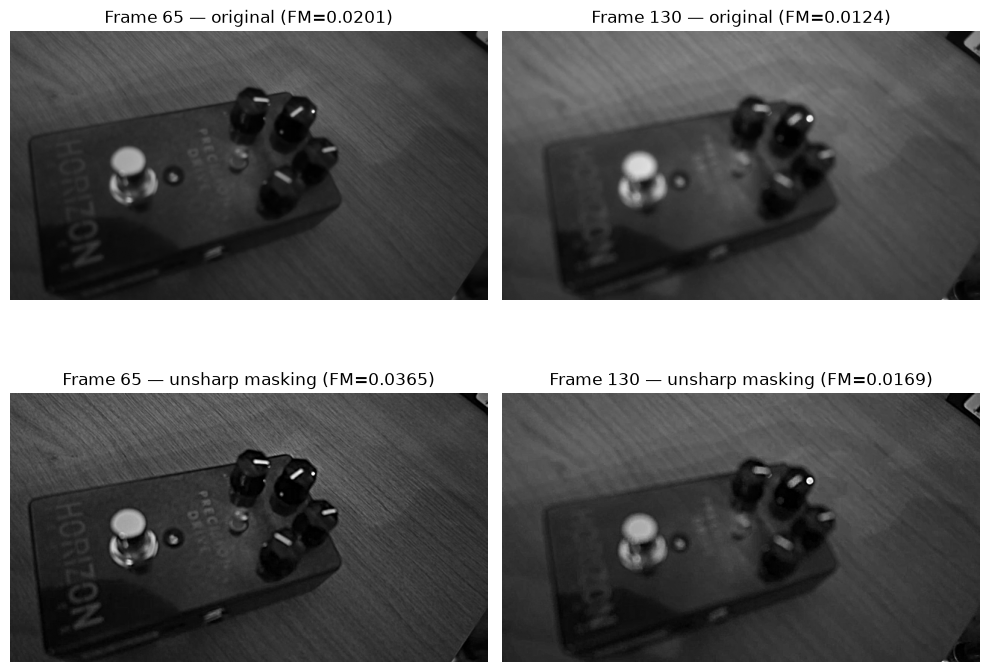

In [13]:
idx_ejemplo = [max(0, zona_full["inicio"] - 15), min(n_frames - 1, zona_full["fin"] + 15)]

fig, axes = plt.subplots(2, len(idx_ejemplo), figsize=(5 * len(idx_ejemplo), 8))
for col, idx in enumerate(idx_ejemplo):
    original = frames_gray[idx]
    reforzada = unsharp_masking(original)

    axes[0, col].imshow(original, cmap="gray")
    axes[0, col].set_title(f"Frame {idx} — original (FM={fm_full[idx]:.4f})")
    axes[0, col].axis("off")

    axes[1, col].imshow(reforzada, cmap="gray")
    axes[1, col].set_title(f"Frame {idx} — unsharp masking (FM={frequency_domain_blur_measure(reforzada):.4f})")
    axes[1, col].axis("off")

fig.tight_layout()
plt.show()

Para medir la expansión de manera justa, no comparamos contra el pico de la curva reforzada (que también sube), sino contra el **mismo umbral absoluto y el mismo pico de referencia** usados para detectar la zona original del Experimento 1. Así aislamos el efecto del unsharp masking sobre el ancho de la zona, y no sobre el valor de FM en sí. Para esto, `detectar_zona_enfoque` acepta un `umbral` y un `centro` explícitos.

In [14]:
frames_sharpened = [unsharp_masking(f) for f in frames_gray]
fm_full_sharpened = np.array([frequency_domain_blur_measure(f) for f in frames_sharpened])

# Mismo umbral absoluto y mismo pico de referencia que la zona original: así medimos
# el efecto del filtro sobre el ANCHO de la zona, no sobre el valor de FM en sí.
zona_full_sharpened = detectar_zona_enfoque(
    fm_full_sharpened, umbral=zona_full["umbral"], centro=zona_full["pico"]
)

ancho_original = zona_full["fin"] - zona_full["inicio"]
ancho_sharpened = zona_full_sharpened["fin"] - zona_full_sharpened["inicio"]

print(f"Zona de enfoque ORIGINAL:            frames [{zona_full['inicio']}, {zona_full['fin']}]  (ancho={ancho_original})")
print(f"Zona de enfoque CON unsharp masking: frames [{zona_full_sharpened['inicio']}, {zona_full_sharpened['fin']}]  (ancho={ancho_sharpened})")
print(f"Expansión: +{ancho_sharpened - ancho_original} frames ({(ancho_sharpened / ancho_original - 1):.0%} más ancha)")

Zona de enfoque ORIGINAL:            frames [80, 115]  (ancho=35)
Zona de enfoque CON unsharp masking: frames [59, 124]  (ancho=65)
Expansión: +30 frames (86% más ancha)


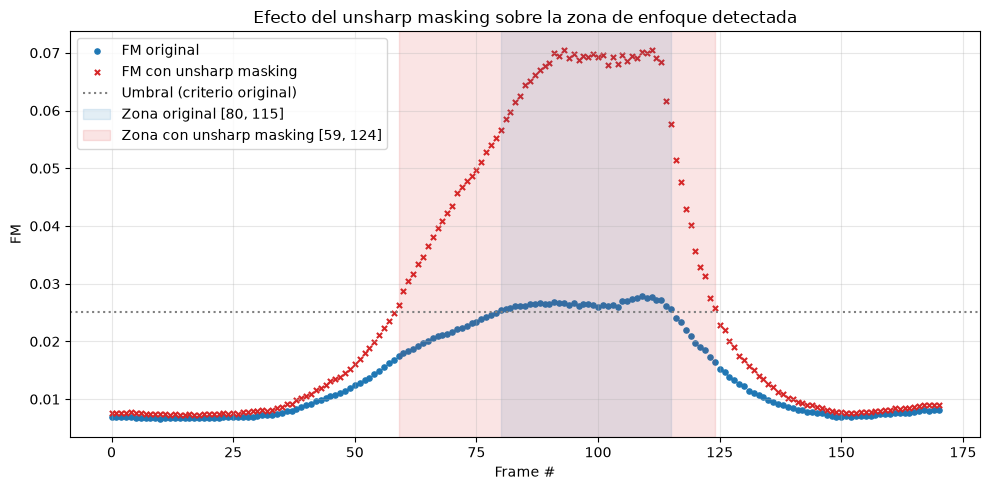

In [15]:
frames_idx = np.arange(n_frames)

plt.figure(figsize=(10, 5))
plt.scatter(frames_idx, fm_full, s=14, color="tab:blue", label="FM original")
plt.scatter(frames_idx, fm_full_sharpened, s=14, color="tab:red", marker="x", label="FM con unsharp masking")

plt.axhline(zona_full["umbral"], color="gray", linestyle=":", label="Umbral (criterio original)")
plt.axvspan(zona_full["inicio"], zona_full["fin"], color="tab:blue", alpha=0.12,
            label=f"Zona original [{zona_full['inicio']}, {zona_full['fin']}]")
plt.axvspan(zona_full_sharpened["inicio"], zona_full_sharpened["fin"], color="tab:red", alpha=0.12,
            label=f"Zona con unsharp masking [{zona_full_sharpened['inicio']}, {zona_full_sharpened['fin']}]")

plt.xlabel("Frame #")
plt.ylabel("FM")
plt.title("Efecto del unsharp masking sobre la zona de enfoque detectada")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Video resultante

Exportamos el video completo (a color) con `unsharp_masking` aplicado sobre cada frame, para poder inspeccionarlo directamente.

In [16]:
OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)
OUTPUT_VIDEO_PATH = os.path.join(OUTPUT_DIR, "focus_video_unsharp_masking.mp4")

frames_bgr_sharpened = [unsharp_masking(f) for f in frames_bgr]

fourcc = cv.VideoWriter_fourcc(*"mp4v")
writer = cv.VideoWriter(OUTPUT_VIDEO_PATH, fourcc, fps, (ancho, alto), isColor=True)
for frame in frames_bgr_sharpened:
    writer.write(frame)
writer.release()

print(f"Video con unsharp masking guardado en: {os.path.abspath(OUTPUT_VIDEO_PATH)}")

Video con unsharp masking guardado en: /Users/feche/maestria IA/CEIA/vision_computadora_I/Codigo/TP2/output/focus_video_unsharp_masking.mp4


<div style="border:2px solid #8EB15C; background-color:#B1CF86; padding:14px 16px; border-radius:6px; color:#111;">

**Conclusiones (punto extra)**

Comparado contra el **mismo umbral absoluto y el mismo pico de referencia** usados para detectar la zona original (ver valores impresos arriba), aplicar unsharp masking sobre cada frame expande claramente el rango de frames considerados "en foco". Esto confirma la hipótesis: el filtro refuerza el contenido de alta frecuencia que los frames cercanos al foco real ya poseían en menor medida, permitiéndoles cruzar el umbral, mientras que los frames muy alejados del foco no tienen alta frecuencia real para reforzar y su FM apenas cambia.

El video resultante queda guardado en `Codigo/TP2/output/focus_video_unsharp_masking.mp4`.

</div>